# Notebook 18: Exploration vs Exploitation

**Series:** Reinforcement Learning Basics (18/20)

---

## 1. The Dilemma

- **Exploit:** Choose the action with highest estimated value (use what you know)
- **Explore:** Try other actions to discover potentially better options

## 2. Undirected Methods

### ε-Greedy
$$a_t = \begin{cases} \arg\max_a Q(a) & \text{with probability } 1-\varepsilon \\ \text{random action} & \text{with probability } \varepsilon \end{cases}$$

### Boltzmann (Softmax)
$$\pi(a) = \frac{\exp(Q(a)/\tau)}{\sum_b \exp(Q(b)/\tau)}$$

$\tau \to 0$: greedy, $\tau \to \infty$: uniform

## 3. Directed Methods

### UCB (Upper Confidence Bound)
$$A_t = \arg\max_a \left[ Q_t(a) + c \sqrt{\frac{\ln t}{N_t(a)}} \right]$$

The bonus term is large for rarely-visited actions → optimism in the face of uncertainty.

### Thompson Sampling
1. Sample $\hat{Q}(a) \sim \text{Posterior}(a)$
2. Act greedily: $a_t = \arg\max_a \hat{Q}(a)$

For Bernoulli bandits: $\hat{Q}(a) \sim \text{Beta}(\alpha_a, \beta_a)$

## 4. Intrinsic Motivation

Add **curiosity bonus** to reward:
$$r_t^{\text{total}} = r_t^{\text{extrinsic}} + \eta \cdot r_t^{\text{intrinsic}}$$

Methods:
- **ICM:** Prediction error of a forward dynamics model
- **RND:** Error of a random network distillation
- **Count-based:** $r^+ = \beta / \sqrt{N(s)}$

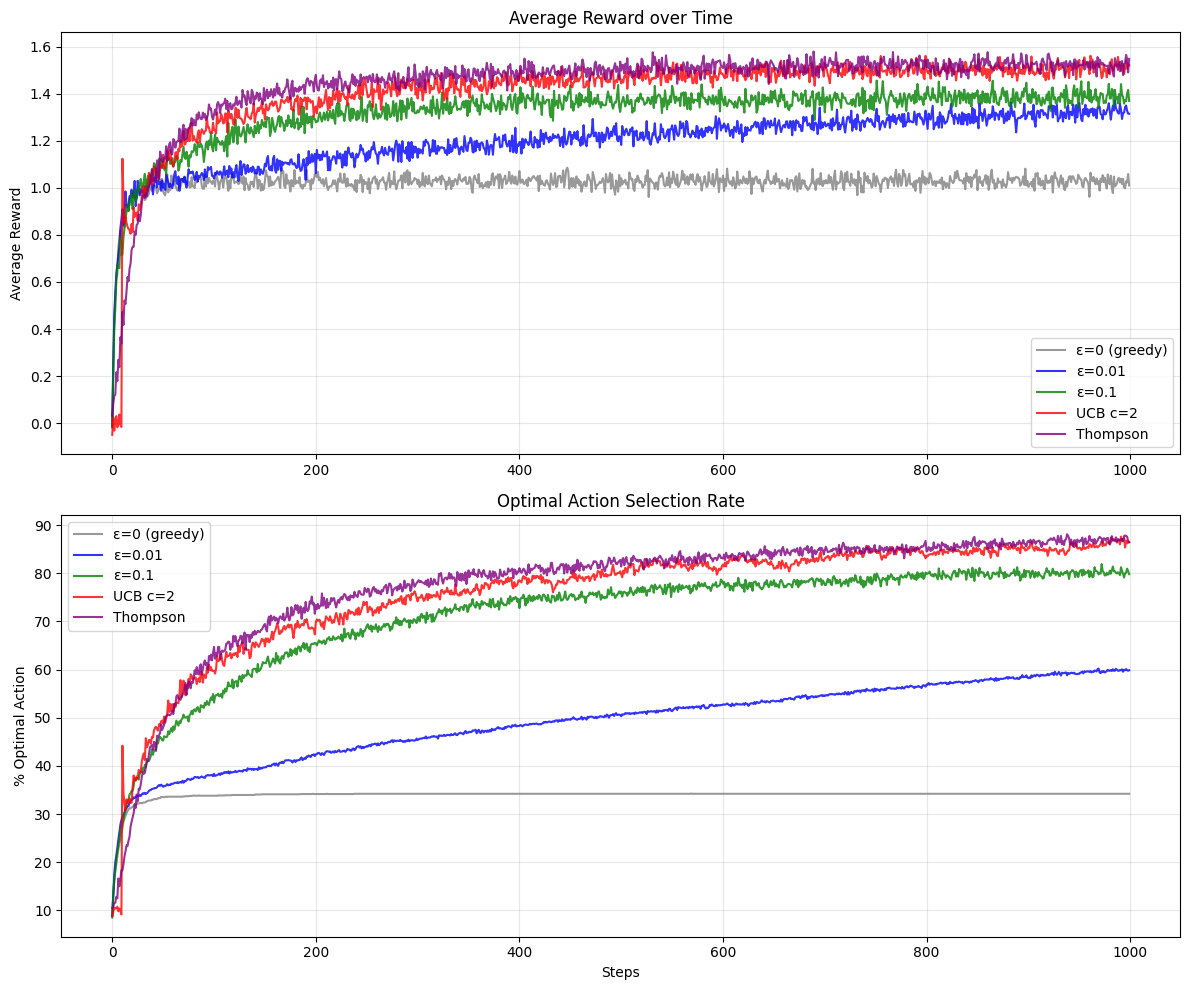

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 10-Armed Bandit Testbed
# ============================================
class Bandit:
    def __init__(self, k=10):
        self.k = k
        self.q_star = np.random.randn(k)  # true action values

    def pull(self, action):
        return np.random.randn() + self.q_star[action]

def run_epsilon_greedy(bandit, epsilon, n_steps=1000):
    Q = np.zeros(bandit.k)
    N = np.zeros(bandit.k)
    rewards = []
    optimal_actions = []
    best_action = np.argmax(bandit.q_star)

    for t in range(n_steps):
        if np.random.random() < epsilon:
            action = np.random.randint(bandit.k)
        else:
            action = np.argmax(Q)
        reward = bandit.pull(action)
        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]
        rewards.append(reward)
        optimal_actions.append(1 if action == best_action else 0)
    return rewards, optimal_actions

def run_ucb(bandit, c=2, n_steps=1000):
    Q = np.zeros(bandit.k)
    N = np.zeros(bandit.k)
    rewards = []; optimal_actions = []
    best_action = np.argmax(bandit.q_star)

    for t in range(n_steps):
        if 0 in N:
            action = np.argmin(N)
        else:
            ucb = Q + c * np.sqrt(np.log(t+1) / N)
            action = np.argmax(ucb)
        reward = bandit.pull(action)
        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]
        rewards.append(reward)
        optimal_actions.append(1 if action == best_action else 0)
    return rewards, optimal_actions

def run_thompson(bandit, n_steps=1000):
    alpha = np.ones(bandit.k)
    beta = np.ones(bandit.k)
    rewards = []; optimal_actions = []
    best_action = np.argmax(bandit.q_star)

    for t in range(n_steps):
        samples = np.random.beta(alpha, beta)
        action = np.argmax(samples)
        reward = bandit.pull(action)
        # Convert to 0/1 for Beta update
        success = 1 if reward > 0 else 0
        alpha[action] += success
        beta[action] += 1 - success
        rewards.append(reward)
        optimal_actions.append(1 if action == best_action else 0)
    return rewards, optimal_actions

# Run experiments
n_runs = 2000; n_steps = 1000
methods = {
    'ε=0 (greedy)': lambda b: run_epsilon_greedy(b, 0),
    'ε=0.01': lambda b: run_epsilon_greedy(b, 0.01),
    'ε=0.1': lambda b: run_epsilon_greedy(b, 0.1),
    'UCB c=2': lambda b: run_ucb(b, c=2),
    'Thompson': lambda b: run_thompson(b),
}

results = {name: {'rewards': np.zeros(n_steps), 'optimal': np.zeros(n_steps)} for name in methods}

for _ in range(n_runs):
    bandit = Bandit(10)
    for name, fn in methods.items():
        r, o = fn(bandit)
        results[name]['rewards'] += np.array(r)
        results[name]['optimal'] += np.array(o)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
colors = ['gray', 'blue', 'green', 'red', 'purple']
for i, (name, data) in enumerate(results.items()):
    axes[0].plot(data['rewards']/n_runs, label=name, color=colors[i], alpha=0.8)
    axes[1].plot(data['optimal']/n_runs*100, label=name, color=colors[i], alpha=0.8)

axes[0].set_ylabel('Average Reward'); axes[0].set_title('Average Reward over Time')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal Action')
axes[1].set_title('Optimal Action Selection Rate')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Method | Exploration Mechanism |
|--------|---------------------|
| **ε-greedy** | Random action with probability ε |
| **Softmax** | Temperature-controlled randomization |
| **UCB** | Confidence-based optimism |
| **Thompson** | Posterior sampling |
| **Intrinsic motivation** | Curiosity/novelty bonus |

**Next:** Notebook 19 — Multi-Armed Bandits